# IEEE-CIS Fraud Detection — Random Forest Model

This notebook trains and evaluates a Random Forest classifier on the preprocessed IEEE-CIS dataset.

**Prerequisites:** Run `Preprocessing.ipynb` first to generate the `preprocessed/` directory.

**Pipeline:**
1. Imports
2. Load preprocessed data
3. Prepare feature matrices
4. Baseline Random Forest (quick sanity check)
5. Hyperparameter tuning with RandomizedSearchCV
6. Train final model
7. Evaluate on validation set
8. Evaluate on test set
9. Feature importance
10. Save model

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    precision_recall_curve,
    RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

RANDOM_STATE = 42
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load Preprocessed Data

Loads the train / val / test CSVs and metadata saved by `Preprocessing.ipynb`.

In [2]:
DATA_DIR = 'preprocessed'

train = pd.read_csv(f'{DATA_DIR}/train.csv')
val   = pd.read_csv(f'{DATA_DIR}/val.csv')
test  = pd.read_csv(f'{DATA_DIR}/test.csv')

with open(f'{DATA_DIR}/column_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

target   = metadata['target']           # 'isFraud'
cat_cols = metadata['cat_cols']         # label-encoded categorical columns
num_cols = metadata['num_cols']         # scaled numerical columns

print(f'Train      : {train.shape} | fraud rate: {train[target].mean():.3%}')
print(f'Validation : {val.shape}   | fraud rate: {val[target].mean():.3%}')
print(f'Test       : {test.shape}  | fraud rate: {test[target].mean():.3%}')
print(f'\nTotal features : {train.shape[1] - 1}')
print(f'  Numerical     : {len(num_cols)}')
print(f'  Categorical   : {len(cat_cols)}')

Train      : (472443, 272) | fraud rate: 3.499%
Validation : (29516, 272)   | fraud rate: 3.500%
Test       : (88581, 272)  | fraud rate: 3.498%

Total features : 271
  Numerical     : 252
  Categorical   : 19


## 3. Prepare Feature Matrices

Random Forest handles all features (numerical + label-encoded categorical) together as a single matrix. No further transformation is needed — the tree splits are invariant to monotonic scaling, so the StandardScaler applied in preprocessing is harmless.

> **Note on class imbalance (~3.5% fraud):** We use `class_weight='balanced'` in the model, which automatically upweights the minority (fraud) class. This is critical for recall on fraud without discarding legitimate transactions.

In [3]:
feature_cols = [c for c in train.columns if c != target]

X_train = train[feature_cols].values
y_train = train[target].values

X_val   = val[feature_cols].values
y_val   = val[target].values

X_test  = test[feature_cols].values
y_test  = test[target].values

print(f'X_train : {X_train.shape}  |  X_val : {X_val.shape}  |  X_test : {X_test.shape}')
print(f'Fraud positives — Train: {y_train.sum():,}  |  Val: {y_val.sum():,}  |  Test: {y_test.sum():,}')

X_train : (472443, 271)  |  X_val : (29516, 271)  |  X_test : (88581, 271)
Fraud positives — Train: 16,531  |  Val: 1,033  |  Test: 3,099


## 4. Baseline Random Forest

A quick baseline with default-ish parameters to confirm the pipeline works end-to-end before tuning.

> This uses `n_jobs=-1` to utilise all available CPU cores. On the full 472K-row training set, expect this to take **5–15 minutes** depending on hardware.

In [4]:
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,          # grow full trees
    min_samples_leaf=5,
    class_weight='balanced', # counter the 3.5% fraud imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)

# Evaluate on validation set
val_probs_base = baseline_rf.predict_proba(X_val)[:, 1]
val_auc_base   = roc_auc_score(y_val, val_probs_base)
val_ap_base    = average_precision_score(y_val, val_probs_base)

print('=== Baseline Results (Validation Set) ===')
print(f'ROC-AUC          : {val_auc_base:.4f}')
print(f'Avg Precision    : {val_ap_base:.4f}   (AP = area under PR curve, more informative for imbalanced data)')

=== Baseline Results (Validation Set) ===
ROC-AUC          : 0.9515
Avg Precision    : 0.7296   (AP = area under PR curve, more informative for imbalanced data)


## 5. Hyperparameter Tuning — RandomizedSearchCV

### Why Randomized over Grid?
With 272 features and 472K rows, exhaustive grid search is prohibitively expensive. `RandomizedSearchCV` samples `n_iter` combinations from the parameter distributions and finds good settings efficiently.

### Scoring metric
We optimise for **ROC-AUC** because it is threshold-independent and a standard metric for this competition. Average Precision (PR-AUC) would also be a reasonable choice for heavily imbalanced data.

> This cell can take **30–90 minutes** depending on hardware. Reduce `n_iter` or `cv` for a faster run.

In [5]:
param_distributions = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 10, 20, 30, 40],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4, 8],
    'max_features'      : ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap'         : [True, False],
    'max_samples'       : [0.6, 0.8, 1.0],  # subsample fraction (only when bootstrap=True)
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=param_distributions,
    n_iter=20,              # number of parameter combinations to try
    scoring='roc_auc',
    cv=cv_strategy,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=1                # parallelism is handled inside the RF itself
)

search.fit(X_train, y_train)

print('\n=== Best Parameters ===')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV ROC-AUC : {search.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END bootstrap=True, max_depth=10, max_features=log2, max_samples=1.0, min_samples_leaf=8, min_samples_split=10, n_estimators=100; total time= 1.1min
[CV] END bootstrap=True, max_depth=10, max_features=log2, max_samples=1.0, min_samples_leaf=8, min_samples_split=10, n_estimators=100; total time= 1.2min
[CV] END bootstrap=True, max_depth=10, max_features=log2, max_samples=1.0, min_samples_leaf=8, min_samples_split=10, n_estimators=100; total time=  59.3s
[CV] END bootstrap=False, max_depth=40, max_features=log2, max_samples=0.8, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   1.7s
[CV] END bootstrap=False, max_depth=40, max_features=log2, max_samples=0.8, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   1.2s
[CV] END bootstrap=False, max_depth=40, max_features=log2, max_samples=0.8, min_samples_leaf=2, min_samples_split=2, n_estimators=300; total time=   1.3s
[CV] END bootst

## 6. Train Final Model

Retrain the best configuration on the **full training set** (not just the CV folds).

In [6]:
best_params = search.best_params_.copy()

# max_samples only applies when bootstrap=True; remove it to avoid sklearn warning
if not best_params.get('bootstrap', True):
    best_params.pop('max_samples', None)

final_rf = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

final_rf.fit(X_train, y_train)
print('Final model trained.')
print(f'  Trees       : {final_rf.n_estimators}')
print(f'  Max depth   : {final_rf.max_depth}')
print(f'  Max features: {final_rf.max_features}')

Final model trained.
  Trees       : 300
  Max depth   : None
  Max features: 0.5


## 7. Output Directory

In [7]:
import datetime, json as _json, time

RUN_NAME = "Random Forest (RandomizedSearchCV)"  # change as needed
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join("model_outputs", f"{TIMESTAMP}_{RUN_NAME.replace(' ', '_')}")
os.makedirs(RUN_DIR, exist_ok=True)
print(f"Run name : {RUN_NAME}")
print(f"Output   : {RUN_DIR}")

Run name : Random Forest (RandomizedSearchCV)
Output   : model_outputs\20260406_140341_Random_Forest_(RandomizedSearchCV)


## 8. Helper Functions

In [8]:
# ── Helper functions (standardised from base_code) ───────────────────────────

def evaluate_metrics(model, X, y):
    """Returns PR-AUC (Average Precision) on the given split."""
    proba = model.predict_proba(X)[:, 1]
    return average_precision_score(y, proba)


def get_predictions(model, X, y):
    """Returns (y_true, y_proba) arrays for the given split."""
    proba = model.predict_proba(X)[:, 1]
    return np.array(y), proba


def plot_confusion_matrix(y_true, y_proba, threshold=0.5, title="Test Set", save_dir='.'):
    y_pred = (y_proba >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[0].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nCounts')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[1].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nRow-normalised')

    plt.tight_layout()
    cm_path = os.path.join(save_dir, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150)
    plt.show()

    print(f"\nClassification Report (threshold={threshold:.3f}):")
    report = classification_report(y_true, y_pred, target_names=['Non-Fraud', 'Fraud'])
    print(report)
    with open(os.path.join(save_dir, 'classification_report.txt'), 'w') as f:
        f.write(f"Threshold: {threshold:.3f}\n\n")
        f.write(report)
    print(f"Confusion matrix saved to {cm_path}")

## 9. Evaluation

In [9]:
val_pr  = evaluate_metrics(final_rf, X_val,  y_val)
test_pr = evaluate_metrics(final_rf, X_test, y_test)

print(f"\n{'='*50}")
print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
print(f"{'='*50}")
print(f"  Val  PR-AUC : {val_pr:.4f}")
print(f"  Test PR-AUC : {test_pr:.4f}")


  Checkpoint PR-AUC (recall deferred to PR curve)
  Val  PR-AUC : 0.7543
  Test PR-AUC : 0.7446


## 10. Plots

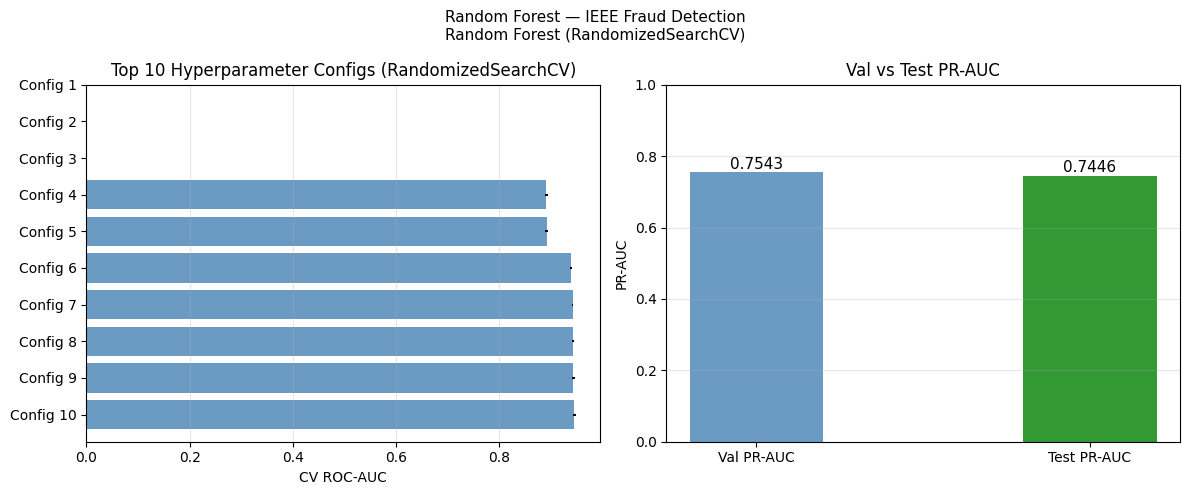

Summary curves saved to model_outputs\20260406_140341_Random_Forest_(RandomizedSearchCV)\rf_summary_curves.png


In [10]:
# ── CV search results: PR-AUC equivalent (ROC-AUC from search, + our PR-AUC) ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: top search configurations ranked by CV ROC-AUC
results_df = (
    pd.DataFrame(search.cv_results_)
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
axes[0].barh(
    results_df.index[::-1],
    results_df['mean_test_score'][::-1],
    xerr=results_df['std_test_score'][::-1],
    color='steelblue', alpha=0.8
)
axes[0].set_xlabel('CV ROC-AUC')
axes[0].set_title('Top 10 Hyperparameter Configs (RandomizedSearchCV)')
axes[0].set_yticks(range(len(results_df)))
axes[0].set_yticklabels([f'Config {i+1}' for i in range(len(results_df))][::-1])
axes[0].grid(alpha=0.3, axis='x')

# Right: val vs test PR-AUC
axes[1].bar(['Val PR-AUC', 'Test PR-AUC'], [val_pr, test_pr],
            color=['steelblue', 'green'], alpha=0.8, width=0.4)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('PR-AUC')
axes[1].set_title('Val vs Test PR-AUC')
for i, v in enumerate([val_pr, test_pr]):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11)
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle(f'Random Forest — IEEE Fraud Detection\n{RUN_NAME}', fontsize=11)
plt.tight_layout()
curves_path = os.path.join(RUN_DIR, 'rf_summary_curves.png')
plt.savefig(curves_path, dpi=150)
plt.show()
print(f"Summary curves saved to {curves_path}")

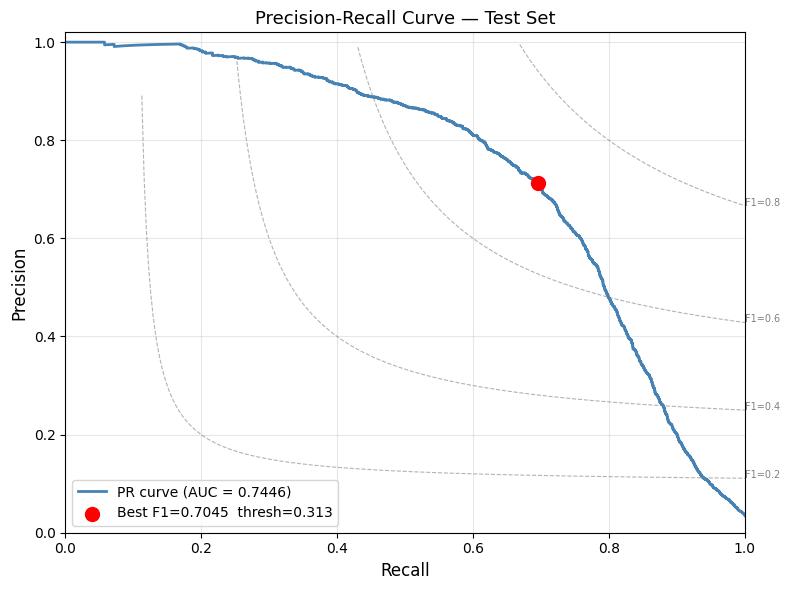

PR curve saved to model_outputs\20260406_140341_Random_Forest_(RandomizedSearchCV)\pr_curve.png


In [11]:
## PR Curve + best threshold based on F1

y_true, y_proba = get_predictions(final_rf, X_test, y_test)

precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

# F1 at every threshold (precision/recall have one extra trailing point — align)
f1_scores_arr = (2 * precision_pts[:-1] * recall_pts[:-1]
                 / (precision_pts[:-1] + recall_pts[:-1] + 1e-8))
best_idx    = np.argmax(f1_scores_arr)
best_thresh = float(thresholds[best_idx])
best_f1     = float(f1_scores_arr[best_idx])

best_recall    = float(recall_pts[best_idx])
best_precision = float(precision_pts[best_idx])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_pts, precision_pts, color='steelblue', lw=2,
        label=f'PR curve (AUC = {test_pr:.4f})')
ax.scatter(best_recall, best_precision, color='red', zorder=5, s=100,
           label=f'Best F1={best_f1:.4f}  thresh={best_thresh:.3f}')

for f1_iso in [0.2, 0.4, 0.6, 0.8]:
    r_vals = np.linspace(0.01, 1.0, 300)
    p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
    mask   = (p_vals >= 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], '--', color='grey', lw=0.8, alpha=0.6)
    ax.annotate(f'F1={f1_iso}', xy=(r_vals[mask][-1], p_vals[mask][-1]),
                fontsize=7, color='grey')

ax.set_xlabel('Recall',    fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Test Set', fontsize=13)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
pr_curve_path = os.path.join(RUN_DIR, 'pr_curve.png')
plt.savefig(pr_curve_path, dpi=150)
plt.show()
print(f"PR curve saved to {pr_curve_path}")

In [12]:
val_y_true, val_proba = get_predictions(final_rf, X_val, y_val)
val_recall  = recall_score(val_y_true,
                           (val_proba  >= best_thresh).astype(int),
                           zero_division=0)
test_recall = best_recall   # already computed above from PR curve

print(f"\n{'='*50}")
print(f"  Final Results at best threshold = {best_thresh:.3f}")
print(f"{'='*50}")
print(f"  Test PR-AUC   : {test_pr:.4f}")
print(f"  Test F1       : {best_f1:.4f}")
print(f"  Test Recall   : {test_recall:.4f}")
print(f"  Test Precision: {best_precision:.4f}")
print(f"  Val  Recall   : {val_recall:.4f}")

# Save final metrics
final_metrics = {
    'run_name'       : RUN_NAME,
    'best_params'    : best_params,
    'best_cv_auc'    : search.best_score_,
    'val_pr_auc'     : val_pr,
    'test_pr_auc'    : test_pr,
    'best_thresh'    : best_thresh,
    'test_f1'        : best_f1,
    'test_recall'    : test_recall,
    'test_precision' : best_precision,
    'val_recall'     : val_recall,
}
metrics_path = os.path.join(RUN_DIR, 'final_metrics.json')
with open(metrics_path, 'w') as f:
    _json.dump(final_metrics, f, indent=2)
print(f"\nFinal metrics saved to {metrics_path}")


  Final Results at best threshold = 0.313
  Test PR-AUC   : 0.7446
  Test F1       : 0.7045
  Test Recall   : 0.6954
  Test Precision: 0.7138
  Val  Recall   : 0.6728

Final metrics saved to model_outputs\20260406_140341_Random_Forest_(RandomizedSearchCV)\final_metrics.json


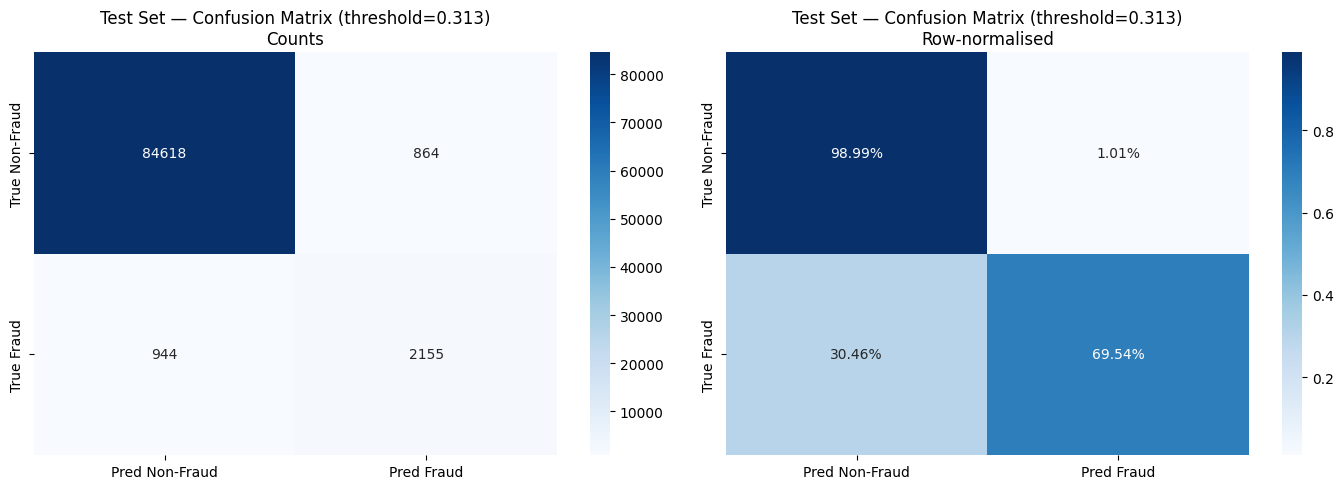


Classification Report (threshold=0.313):
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     85482
       Fraud       0.71      0.70      0.70      3099

    accuracy                           0.98     88581
   macro avg       0.85      0.84      0.85     88581
weighted avg       0.98      0.98      0.98     88581

Confusion matrix saved to model_outputs\20260406_140341_Random_Forest_(RandomizedSearchCV)\confusion_matrix.png


In [13]:
plot_confusion_matrix(y_true, y_proba, threshold=best_thresh, save_dir=RUN_DIR)

## 11. Feature Importance

Plots the top 30 features by mean decrease in impurity (MDI). 

> **Caveat:** MDI importance can overestimate high-cardinality features (like `card1`). For a more reliable ranking, consider permutation importance (`sklearn.inspection.permutation_importance`) at the cost of extra compute time.

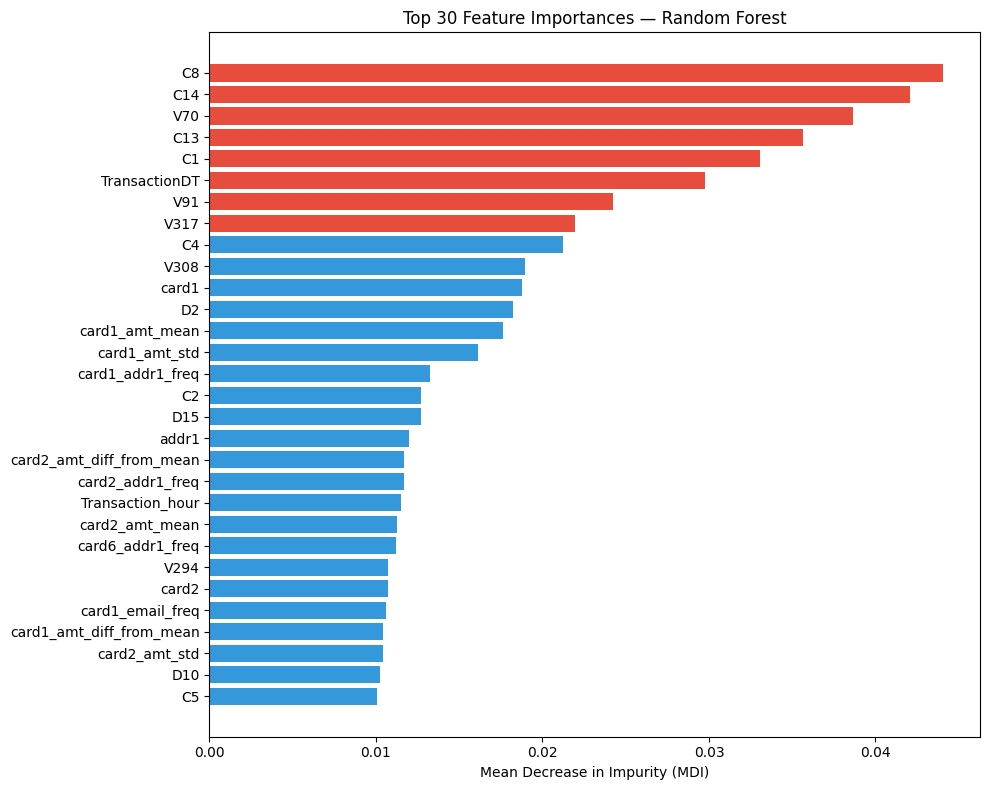


Top 15 features:
         feature  importance
              C8    0.044074
             C14    0.042079
             V70    0.038648
             C13    0.035650
              C1    0.033072
   TransactionDT    0.029790
             V91    0.024216
            V317    0.021963
              C4    0.021243
            V308    0.018963
           card1    0.018755
              D2    0.018258
  card1_amt_mean    0.017650
   card1_amt_std    0.016145
card1_addr1_freq    0.013216

Saved: preprocessed/feature_importance.csv


In [14]:
importances = final_rf.feature_importances_
importance_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

TOP_N = 30
top_df = importance_df.head(TOP_N)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if imp > top_df['importance'].quantile(0.75) else '#3498db'
          for imp in top_df['importance']]
plt.barh(top_df['feature'][::-1], top_df['importance'][::-1], color=colors[::-1])
plt.xlabel('Mean Decrease in Impurity (MDI)')
plt.title(f'Top {TOP_N} Feature Importances — Random Forest')
plt.tight_layout()
plt.savefig('preprocessed/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 15 features:')
print(importance_df.head(15).to_string(index=False))

importance_df.to_csv('preprocessed/feature_importance.csv', index=False)
print('\nSaved: preprocessed/feature_importance.csv')

## 12. Save Model

In [ ]:
model_path = os.path.join(RUN_DIR, 'rf_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(final_rf, f)
print(f"Model saved to {model_path}")

print(f"\n{'='*50}")
print(f"  All outputs saved to: {RUN_DIR}/")
print(f"    rf_summary_curves.png")
print(f"    pr_curve.png")
print(f"    confusion_matrix.png")
print(f"    classification_report.txt")
print(f"    feature_importance.png")
print(f"    feature_importance.csv")
print(f"    final_metrics.json")
print(f"    rf_model.pkl")
print(f"{'='*50}")